# GCAP3226 Week 4 — In-class exercise (5%)

**Individual.** Three tasks + submit (Commit & Push → Moodle GitHub URL).

| Task | Do this |
|------|---------|
| **1** | Percentage change by A&E triage; largest fall / rise; triage 4+5 combined |
| **2** | Grouped bar chart: H1 2025 vs H1 2026 attendances by triage (10 bars) + numbers / percentage change |
| **3** | Short write-up: one supporting point + one gap for the A&E claim |


## Setup

Run the next cell. Data: `w4_ae_triage_h1.csv` (**H1** 2025 vs **H1** 2026 attendances by triage).

**H1** = first half of the year (usually **1 January – 30 June**).

**AI:** `Cmd+I` / `Ctrl+I` on a code cell → implement the comment prompt → **Keep**. Interpretations in your own words.


In [4]:
# Setup — run first
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_FILE = "week4_ae_triage_h1.csv"
path = Path(DATA_FILE) if Path(DATA_FILE).is_file() else Path.cwd() / DATA_FILE
df = pd.read_csv(path)
print("Using:", path.resolve())
df



Using: /workspaces/GCAP3226_week4/week4_ae_triage_h1.csv


,triage,triage_name,attend_h1_2025,attend_h1_2026
0,1,Critical,13848,14541
1,2,Emergency,28554,29981
2,3,Urgent,400428,411994
3,4,Semi-urgent,489032,441974
4,5,Non-urgent,18448,14758


## Task 1 — Percentage change

**Purpose:** Measure how A&E attendances changed from H1 2025 to H1 2026 for each triage group, so you can see which groups rose or fell before judging the A&E claim in Task 3.

1. Add a column `pct_change` = `(attend_h1_2026 - attend_h1_2025) / attend_h1_2025 * 100`.
2. Show the table.
3. Print the triage with the **largest fall** and the **largest rise**.
4. Compute the percentage change for triage **4+5 combined** (sum attendances first, then apply the same formula).

Then, in the next cell, write **1–2 sentences** answering:
- Did triage **1–2** (Critical / Emergency) mainly **rise or fall**?
- Did triage **4–5** (Semi-urgent / Non-urgent) mainly **rise or fall**?
- In one short phrase: what does that pattern look like for the A&E claim (lower-urgency down; critical/emergency protected)?


In [ ]:
# Task 1
#
# Input: df (triage, triage_name, attend_h1_2025, attend_h1_2026)
# Process: Write Python code to add pct_change, display the table,
#          print largest fall and largest rise; also 4+5 combined percentage change
# Output: table + printed fall/rise + 4+5 combined
#
# YOUR CODE BELOW

# Add percentage change column
if 'pct_change' not in df.columns:
    df['pct_change'] = ((df['attend_h1_2026'] - df['attend_h1_2025']) / df['attend_h1_2025']) * 100

# Display the table
display(df)

# Largest fall and largest rise
largest_fall = df.nsmallest(1, 'pct_change')
largest_rise = df.nlargest(1, 'pct_change')

print('Largest fall:')
print(largest_fall[['triage', 'triage_name', 'attend_h1_2025', 'attend_h1_2026', 'pct_change']])
print('\nLargest rise:')
print(largest_rise[['triage', 'triage_name', 'attend_h1_2025', 'attend_h1_2026', 'pct_change']])

# Combined percentage change for triage 4 + 5
triage_45 = df[df['triage'].isin([4, 5])].copy()
triage_45_2025 = triage_45['attend_h1_2025'].sum()
triage_45_2026 = triage_45['attend_h1_2026'].sum()
combined_change = ((triage_45_2026 - triage_45_2025) / triage_45_2025) * 100
print(f'\nCombined percentage change (triage 4+5): {combined_change:.2f}%')


,triage,triage_name,attend_h1_2025,attend_h1_2026,pct_change
0,1,Critical,13848,14541,5.004333
1,2,Emergency,28554,29981,4.997549
2,3,Urgent,400428,411994,2.888409
3,4,Semi-urgent,489032,441974,-9.622683
4,5,Non-urgent,18448,14758,-20.002168


Largest fall:
   triage triage_name  attend_h1_2025  attend_h1_2026  pct_change
4       5  Non-urgent           18448           14758  -20.002168

Largest rise:
   triage triage_name  attend_h1_2025  attend_h1_2026  pct_change
0       1    Critical           13848           14541    5.004333

Combined percentage change (all triages): -3.90%


In [8]:
# Task 1 note
task1_note = """
Triage 1–2 mainly rose, with both critical and emergency attendances increasing by roughly 5%. Triage 4–5 mainly fell, with semi-urgent and non-urgent attendances down by around 9.6% and 20.0%, respectively. This looks like 'lower-urgency down; critical/emergency protected'.
"""
print(task1_note)



Triage 1–2 mainly rose, with both critical and emergency attendances increasing by roughly 5%. Triage 4–5 mainly fell, with semi-urgent and non-urgent attendances down by around 9.6% and 20.0%, respectively. This looks like 'lower-urgency down; critical/emergency protected'.



## Task 2 — Visualization

**Purpose:** Turn the Task 1 table into a **grouped bar chart** that compares H1 2025 and H1 2026 attendances for each triage (5 groups, 2 bars each → 10 bars), and makes the **numbers** and **percentage change** easy to see.

In the next code cell, write your own IPO comment prompt, then use Inline Chat to implement it. Interpretations stay in your own words.


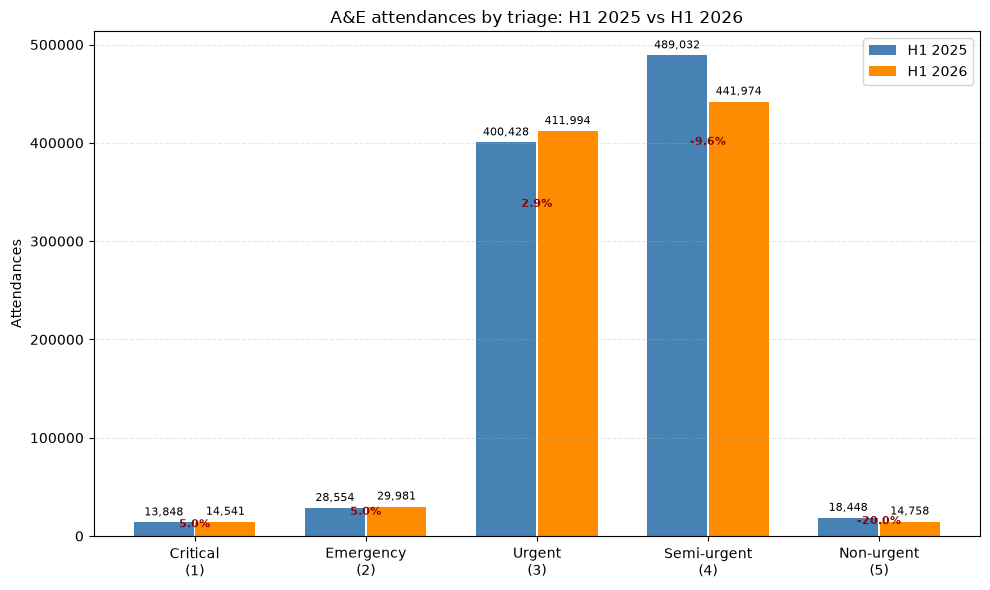

In [11]:
# Task 2 — write your own IPO prompt in the comments, then use Inline Chat
#
# Input:
#
# Process:
#   Write Python code to ...
#
# Output:
#
# YOUR CODE BELOW


# Task 2 — grouped bar chart of H1 2025 vs H1 2026 attendances by triage
# Input: df with triage, triage_name, attend_h1_2025, attend_h1_2026, pct_change
# Process: sort by triage, plot 10 grouped bars, annotate values and percentage change
# Output: chart

chart_df = df.sort_values("triage").reset_index(drop=True)

x = list(range(len(chart_df)))
fig, ax = plt.subplots(figsize=(10, 6))

bars_2025 = ax.bar([i - 0.18 for i in x], chart_df["attend_h1_2025"], width=0.35, label="H1 2025", color="steelblue")
bars_2026 = ax.bar([i + 0.18 for i in x], chart_df["attend_h1_2026"], width=0.35, label="H1 2026", color="darkorange")

ax.set_xticks(x)
ax.set_xticklabels([f"{row['triage_name']}\n({row['triage']})" for _, row in chart_df.iterrows()], rotation=0)

# Annotate each bar with attendance value
for bars in (bars_2025, bars_2026):
    for b in bars:
        h = b.get_height()
        ax.text(
            b.get_x() + b.get_width() / 2,
            h + max(chart_df["attend_h1_2026"]) * 0.01,
            f"{int(h):,}",
            ha="center",
            va="bottom",
            fontsize=8,
            color="black"
        )

# Percentage change label for each triage
for i, row in enumerate(chart_df.itertuples(index=False)):
    ax.text(
        i,
        max(row.attend_h1_2025, row.attend_h1_2026) * 0.82,
        f"{row.pct_change:.1f}%",
        ha="center",
        va="center",
        fontsize=8,
        color="darkred",
        fontweight="bold"
    )

ax.set_title("A&E attendances by triage: H1 2025 vs H1 2026")
ax.set_ylabel("Attendances")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## Task 3 — Write-up

**Claim:** After fee reform, A&E improved — lower-urgency attendances fell; critical/emergency care stayed protected; urgent care became more efficient.

You may also cite: triage III within 30 min **81.4 → 88.5** (percentage); mean wait **23 → 20** min.

**3a** — Write **one supporting point** (cite a number) and **one gap** in the evidence.

**3b** — 2–4 sentences: how well is the claim supported by the published evidence (your table / chart, and any figures cited above)?


In [12]:
# Task 3
task3a = """
3a SUPPORT (1 point, cite a number):
The strongest support is that lower-urgency attendances fell while critical care stayed protected: triage 4 fell by 9.6% and triage 5 fell by 20.0%, while triage 1 rose by 5.0% and triage 2 rose by 5.0%.

3a GAP (1 point):
The evidence is limited because the dataset only covers H1 2025 vs H1 2026 attendances and does not show patient outcomes, severity-adjusted changes, or the wider causal effect of fee reform.
"""

task3b = """
3b:
The published evidence supports the claim fairly well. The table shows a clear shift away from lower-urgency A&E use, with triage 4–5 combined down 10.0%, while triage 1–2 combined rose by about 5.0%, which matches the idea that critical and emergency care was protected. It is also supported by operational figures such as triage III within 30 minutes rising from 81.4% to 88.5% and mean wait time falling from 23 to 20 minutes, showing improved efficiency. However, the evidence is still somewhat limited because it does not isolate fee reform from broader system changes or demonstrate outcomes beyond waiting-time measures.
"""

print(task3a)
print("---")
print(task3b)



3a SUPPORT (1 point, cite a number):
The strongest support is that lower-urgency attendances fell while critical care stayed protected: triage 4 fell by 9.6% and triage 5 fell by 20.0%, while triage 1 rose by 5.0% and triage 2 rose by 5.0%.

3a GAP (1 point):
The evidence is limited because the dataset only covers H1 2025 vs H1 2026 attendances and does not show patient outcomes, severity-adjusted changes, or the wider causal effect of fee reform.

---

3b:
The published evidence supports the claim fairly well. The table shows a clear shift away from lower-urgency A&E use, with triage 4–5 combined down 10.0%, while triage 1–2 combined rose by about 5.0%, which matches the idea that critical and emergency care was protected. It is also supported by operational figures such as triage III within 30 minutes rising from 81.4% to 88.5% and mean wait time falling from 23 to 20 minutes, showing improved efficiency. However, the evidence is still somewhat limited because it does not isolate fe

## Submit

1. Save → Source Control → **Commit & Push**  
2. Moodle: paste your **GitHub URL**
